In [ ]:
import pandas as pd

df = pd.read_parquet("../data/processed/topic_modeling_result.parquet")
df

In [ ]:
df_politic = df[df["political_category"] == "Politic"].copy()
df_politic.groupby(by="macro_topic").size().sort_values(ascending=False)

In [6]:
df_reduce = pd.read_parquet("../reports/topic_modeling/best_result_reduced_p/all-distilroberta-v1/post_topics.parquet")
df_reduce

,id,topic
0,965539,2
1,966204,2
2,975203,2
3,1423128,3
4,1380349,3
...,...,...
996050,284307,-1
996051,848845,10
996052,12647,231
996053,12948,231


In [5]:
df = pd.read_parquet("../reports/topic_modeling/best_result/all-distilroberta-v1/post_topics.parquet")
df

,id,topic
0,965539,-1
1,966204,2
2,975203,-1
3,1423128,3
4,1380349,3
...,...,...
996050,284307,-1
996051,848845,10
996052,12647,-1
996053,12948,-1


In [13]:
import json
import pandas as pd

with open("../reports/topic_modeling/macro_topics.json", "r", encoding="utf-8") as f:
    macro_data = json.load(f)

# Converter as chaves do JSON de string -> int
topic_to_macro = {
    int(topic_id): macro
    for topic_id, macro in macro_data["topic_id_to_macro"].items()
}

# Macro topic -> se é político
macro_to_political = {
    macro: info["Politics_related"]
    for macro, info in macro_data["macro_topics"].items()
}

# Adicionar macrotopic
df_reduce["macrotopic"] = df_reduce["topic"].map(topic_to_macro)

# Adicionar indicador político
df_reduce["is_political"] = df_reduce["macrotopic"].map(macro_to_political)

In [15]:
df["macrotopic"] = df["topic"].map(topic_to_macro)

# Adicionar indicador político
df["is_political"] = df["macrotopic"].map(macro_to_political)

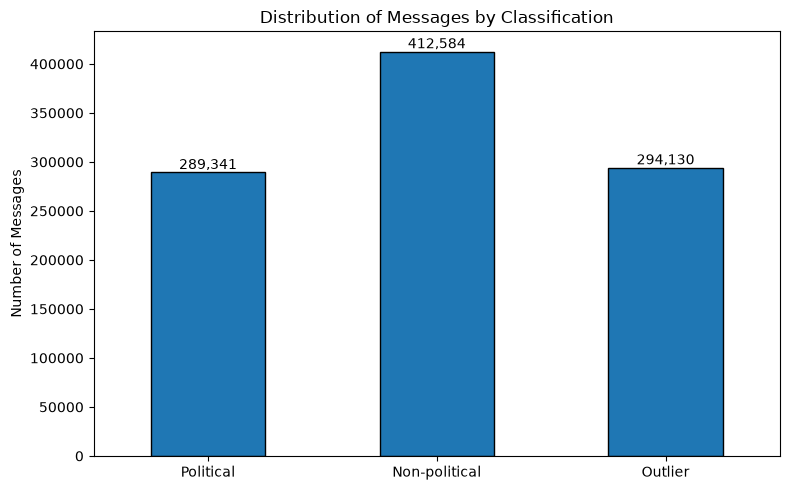

In [19]:
import matplotlib.pyplot as plt

df_reduce["type"] = df_reduce["is_political"].map({
    True: "Political",
    False: "Non-political"
})

# HDBSCAN outliers
df_reduce.loc[df_reduce["topic"] == -1, "type"] = "Outlier"

# Fixed order
order = ["Political", "Non-political", "Outlier"]

count = (
    df_reduce["type"]
    .value_counts()
    .reindex(order)
)

plt.figure(figsize=(8, 5))

ax = count.plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Distribution of Messages by Classification")
plt.xlabel("")
plt.ylabel("Number of Messages")
plt.xticks(rotation=0)

# Values above bars
for i, v in enumerate(count):
    ax.text(
        i,
        v,
        f"{v:,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

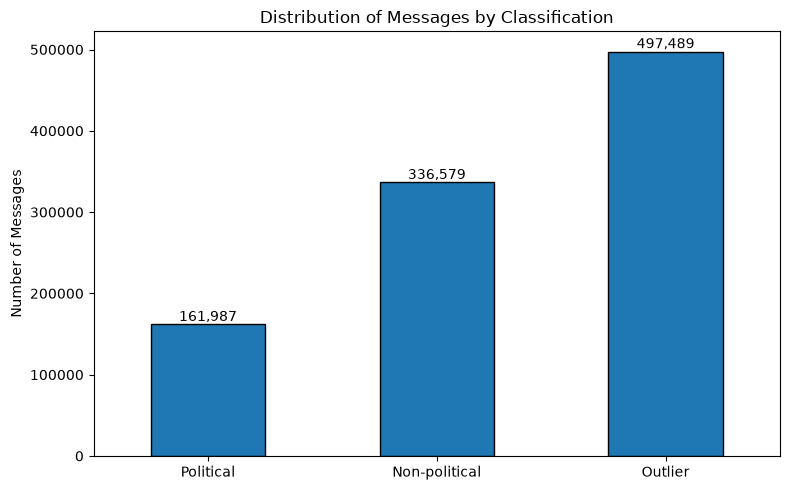

In [20]:
df["type"] = df["is_political"].map({
    True: "Political",
    False: "Non-political"
})

# HDBSCAN outliers
df.loc[df["topic"] == -1, "type"] = "Outlier"

# Fixed order
order = ["Political", "Non-political", "Outlier"]

count = (
    df["type"]
    .value_counts()
    .reindex(order)
)

plt.figure(figsize=(8, 5))

ax = count.plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Distribution of Messages by Classification")
plt.xlabel("")
plt.ylabel("Number of Messages")
plt.xticks(rotation=0)

# Values above bars
for i, v in enumerate(count):
    ax.text(
        i,
        v,
        f"{v:,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [22]:
df["macrotopic"].unique()

<ArrowStringArray>
[                                     nan,
                         'CRYPTO_TRADING',
          'CHITCHAT_LIFESTYLE_MODERATION',
                  'RELIGION_SPIRITUALITY',
                  'HEALTH_ANTIVAX_ALTMED',
                     'WAR_RUSSIA_UKRAINE',
                 'CRIME_POLICING_JUSTICE',
                  'US_POLITICS_ELECTIONS',
               'NATIONAL_POLITICS_NON_US',
               'CRYPTO_COORDINATED_RAIDS',
          'IDENTITY_BASED_HATE_AND_SLURS',
            'CONSPIRACY_DEEPSTATE_ELITES',
            'DISASTERS_ACCIDENTS_HAZARDS',
             'IDEOLOGY_ANTIESTABLISHMENT',
                        'WAR_MIDDLE_EAST',
                        'MEDIA_PLATFORMS',
                      'SCAMS_FRAUD_GRIFT',
                   'PROTEST_MOBILIZATION',
               'CONSPIRACY_PSEUDOSCIENCE',
             'FREE_SPEECH_AND_CENSORSHIP',
                            'MORAL_PANIC',
                    'IMMIGRATION_BORDERS',
                 'GEOPOLITICS_INTER